In [15]:
from PIL import Image, ImageOps
import numpy as np
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

[[0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 0.]
 [0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]] 3


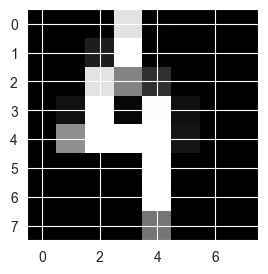

In [16]:
digits = datasets.load_digits()
X, y = digits.data, digits.target
clf = LogisticRegression(max_iter=5000)
clf.fit(X, y)

image = Image.open("cetiri.png").convert("L")
image = image.resize((8, 8), Image.BILINEAR)
plt.figure(figsize=(3, 3))
plt.imshow(image, cmap="gray")

array = np.asarray(image).astype(np.float32) / 255.0
print(np.round(array), 3)


In [18]:
x_norm = (array*16.0).reshape(1, -1)
print(x_norm)

proba_norm = clf.predict_proba(x_norm)[0]
print(proba_norm)

pred_norm = np.argmax(proba_norm)
final = int(pred_norm)
final_conf = float(proba_norm[final])

print('Final', final)
print('Final confidence', final_conf)
for digit, p in enumerate(proba_norm):
    print(f"{digit}: {p:.4f}")

[[ 0.         0.         0.        14.305882   0.1254902  0.
   0.         0.         0.         0.         1.8196079 16.
   0.         0.         0.         0.         0.         0.
  14.243137   8.219608   3.0745099  0.         0.         0.
   0.         1.0666667 16.         0.4392157 15.937255   1.0039216
   0.         0.         0.         8.972549  16.        16.
  16.         1.3176471  0.         0.         0.         0.
   0.         0.        16.         0.0627451  0.         0.
   0.         0.         0.         0.0627451 16.         0.
   0.         0.         0.         0.         0.         0.
   7.3411765  0.         0.         0.       ]]
[1.85129556e-11 2.07913676e-03 2.99978827e-20 2.87151768e-11
 9.97158362e-01 5.23649978e-07 7.61545180e-04 3.98822372e-08
 3.91021323e-07 9.86683267e-10]
Final 4
Final confidence 0.9971583624738135
0: 0.0000
1: 0.0021
2: 0.0000
3: 0.0000
4: 0.9972
5: 0.0000
6: 0.0008
7: 0.0000
8: 0.0000
9: 0.0000
